In [1]:
# Pandas dtypes to load for training

train_dtypes = {
    'ProductName':                                                  'float32',
    'IsBeta':                                                       'float32',
    'RtpStateBitfield':                                             'float32',
    'IsSxsPassiveMode':                                             'float32',
    'DefaultBrowsersIdentifier':                                    'float32',
    'AVProductStatesIdentifier':                                    'float32',
    'AVProductsInstalled':                                          'float32',
    'AVProductsEnabled':                                            'float32',
    'HasTpm':                                                       'float32',
    'CountryIdentifier':                                            'float32',
    'CityIdentifier':                                               'float32',
    'OrganizationIdentifier':                                       'float32',
    'GeoNameIdentifier':                                            'float32',
    'LocaleEnglishNameIdentifier':                                  'float32',
    'Platform':                                                     'float32',
    'Processor':                                                    'float32',
    'OsVer':                                                        'float32',
    'OsBuild':                                                      'float32',
    'OsSuite':                                                      'float32',
    'OsPlatformSubRelease':                                         'float32',
    'OsBuildLab':                                                   'float32',
    'SkuEdition':                                                   'float32',
    'IsProtected':                                                  'float32',
    'AutoSampleOptIn':                                              'float32',
    'PuaMode':                                                      'float32',
    'SMode':                                                        'float32',
    'IeVerIdentifier':                                              'float32',
    'SmartScreen':                                                  'float32',
    'Firewall':                                                     'float32',
    'UacLuaenable':                                                 'float32',
    'Census_MDC2FormFactor':                                        'float32',
    'Census_DeviceFamily':                                          'float32',
    'Census_OEMNameIdentifier':                                     'float32',
    'Census_OEMModelIdentifier':                                    'float32',
    'Census_ProcessorCoreCount':                                    'float32',
    'Census_ProcessorManufacturerIdentifier':                       'float32',
    'Census_ProcessorModelIdentifier':                              'float32',
    'Census_ProcessorClass':                                        'float32',
    'Census_PrimaryDiskTotalCapacity':                              'float32',
    'Census_PrimaryDiskTypeName':                                   'float32',
    'Census_SystemVolumeTotalCapacity':                             'float32',
    'Census_HasOpticalDiskDrive':                                   'float32',
    'Census_TotalPhysicalRAM':                                      'float32',
    'Census_ChassisTypeName':                                       'float32',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches':            'float32',
    'Census_InternalPrimaryDisplayResolutionHorizontal':            'float32',
    'Census_InternalPrimaryDisplayResolutionVertical':              'float32',
    'Census_PowerPlatformRoleName':                                 'float32',
    'Census_InternalBatteryType':                                   'float32',
    'Census_InternalBatteryNumberOfCharges':                        'float32',
    'Census_OSArchitecture':                                        'float32',
    'Census_OSBranch':                                              'float32',
    'Census_OSBuildNumber':                                         'float32',
    'Census_OSBuildRevision':                                       'float32',
    'Census_OSEdition':                                             'float32',
    'Census_OSSkuName':                                             'float32',
    'Census_OSInstallTypeName':                                     'float32',
    'Census_OSInstallLanguageIdentifier':                           'float32',
    'Census_OSUILocaleIdentifier':                                  'float32',
    'Census_OSWUAutoUpdateOptionsName':                             'float32',
    'Census_IsPortableOperatingSystem':                             'float32',
    'Census_GenuineStateName':                                      'float32',
    'Census_ActivationChannel':                                     'float32',
    'Census_IsFlightingInternal':                                   'float32',
    'Census_IsFlightsDisabled':                                     'float32',
    'Census_FlightRing':                                            'float32',
    'Census_ThresholdOptIn':                                        'float32',
    'Census_FirmwareManufacturerIdentifier':                        'float32',
    'Census_FirmwareVersionIdentifier':                             'float32',
    'Census_IsSecureBootEnabled':                                   'float32',
    'Census_IsWIMBootEnabled':                                      'float32',
    'Census_IsVirtualDevice':                                       'float32',
    'Census_IsTouchEnabled':                                        'float32',
    'Census_IsPenCapable':                                          'float32',
    'Census_IsAlwaysOnAlwaysConnectedCapable':                      'float32',
    'Wdft_IsGamer':                                                 'float32',
    'Wdft_RegionIdentifier':                                        'float32',
    'EngineVersion_1':                                              'int8',
    'EngineVersion_2':                                              'int8',
    'EngineVersion_3':                                              'float32',
    'EngineVersion_4':                                              'float32',
    'AppVersion_1':                                                 'int8',
    'AppVersion_2':                                                 'float32',
    'AppVersion_3':                                                 'float32',
    'AppVersion_4':                                                 'float32',
    'AvSigVersion_1':                                               'float32',
    'AvSigVersion_2':                                               'float32',
    'AvSigVersion_3':                                               'float32',
    'AvSigVersion_4':                                               'int8',
    'Census_OSVersion_1':                                           'float32',
    'Census_OSVersion_2':                                           'float32',
    'Census_OSVersion_3':                                           'float32',
    'Census_OSVersion_4':                                           'float32',
    'HasDetections':                                                'int8',
}

In [2]:
# Import statements

import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
# Define location of training and valing data

train_dir='/Users/dragonfruit/cs6140-ml-workspace/ML-project/data/train_data_scaled_encoded_shrunk.csv'
val_dir='/Users/dragonfruit/cs6140-ml-workspace/ML-project/data/validation_data_scaled_encoded_shrunk.csv'

In [4]:
def plot_train_accuracy(train_accuracies, val_accuracies=None, record_interval=2):
    """
    Plots the training accuracy over epochs, considering recording intervals.

    Parameters:
        train_accuracies (list): A list of training accuracy values recorded every `record_interval` epochs.
        val_accuracies (list, optional): A list of validation accuracy values recorded every `record_interval` epochs.
        record_interval (int): The interval at which accuracy is recorded (default is 2 epochs).
    """
    epochs = list(range(record_interval, (len(train_accuracies) * record_interval) + 1, record_interval))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o', linestyle='-')

    if val_accuracies:
        plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='s', linestyle='--')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Complex Model - Baseline

* 100 epochs
* Train loader batch size: 4096
* val loader batch size: 4096

In [5]:
# PCA features
features = [
    "Census_OSBuildNumber",
    "OsBuild",
    "Census_InternalBatteryType",
    "Census_InternalBatteryNumberOfCharges",
    "Census_IsWIMBootEnabled",
    "Census_ThresholdOptIn",
    "OsVer",
    "Platform",
    "Census_ChassisTypeName",
    "Census_MDC2FormFactor",
    "Census_InternalPrimaryDisplayResolutionVertical",
    "Census_OSSkuName",
    "AppVersion",
    "Census_OSEdition",
    "OsSuite",
    "Census_InternalPrimaryDisplayResolutionHorizontal",
    "Census_InternalPrimaryDiagonalDisplaySizeInInches",
    "SkuEdition",
    "OsBuildLab",
    "Census_OSVersion",
    "SmartScreen",
    "Census_TotalPhysicalRAM",
    "Census_OSBranch",
    "Census_PowerPlatformRoleName",
    "ProductName",
    "Census_IsFlightingInternal",
    "HasTpm",
    "Census_ProcessorCoreCount",
    "Census_OSBuildRevision",
    "OsPlatformSubRelease",
    "Census_IsFlightsDisabled",
    "Census_FirmwareManufacturerIdentifier",
    "Census_IsSecureBootEnabled",
    "Firewall",
    "Census_FlightRing",
    "Census_PrimaryDiskTypeName",
    "EngineVersion",
    "IeVerIdentifier",
    "Census_ProcessorModelIdentifier",
    "Census_FirmwareVersionIdentifier",
    "Census_ProcessorClass",
    "AVProductsInstalled",
    "Wdft_IsGamer",
    "Census_OEMNameIdentifier",
    "IsProtected",
    "Processor",
    "Census_OSArchitecture",
    "AVProductStatesIdentifier",
    "SMode",
    "Census_OEMModelIdentifier",
    "Wdft_RegionIdentifier",
    "Census_OSInstallLanguageIdentifier",
    "DefaultBrowsersIdentifier",
    "AVProductsEnabled",
    "Census_GenuineStateName",
    "AvSigVersion",
    "Census_OSWUAutoUpdateOptionsName"
]

In [6]:
# Load training and valing data into Pandas

train=pd.read_csv(train_dir, dtype=train_dtypes)
X_train_scaled = train[features]
y_train = train['HasDetections']

del train

val=pd.read_csv(val_dir, dtype=train_dtypes)
X_val_scaled = val[features]
y_val = val['HasDetections']

del val

In [7]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Create datasets and data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_batch_size = 4096
val_batch_size = 4096

# Pin memory only speeds up CPU to GPU transfers if the device is CUDA enabled
if torch.cuda.is_available():
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False, pin_memory=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False)

In [9]:
# Define complex model
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

In [10]:
# Define training variables

input_dim = X_train_tensor.shape[1]
model = BinaryClassifier(input_dim)

# Use AdamW optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.BCELoss()

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Epochs
epochs = 100

# Figure out which device to use. By default, CPU
device = "cpu"
# For M-architecture Macs
if torch.backends.mps.is_available():
    device = torch.device("mps")
# For NVIDIA
elif torch.cuda.is_available():
    device = torch.device("cuda")


In [11]:
# Transfer the tensors to the appropriate device
X_train_tensor = X_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

# Transfer the model to the appropriate device
model.to(device)
        
total_train_accuracies = []
total_val_accuracies = []

for epoch in range(epochs):
    model.train()
    # Initialize training loss
    total_train_loss = 0.0
    with tqdm(train_loader, desc=f"Epochs: {epoch+1}/{epochs}") as pbar:
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_train_loss += loss.item()
            loss.backward()
            optimizer.step()
            # Delete after use
            del inputs, targets, loss
        # Calculate the average training loss
        average_train_loss = total_train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item()
            # Delete after use
            del inputs, targets
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    # Print learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{epochs}, Training Loss: {average_train_loss:.4f}, Validation Loss: {val_loss:.4f}, Learning Rate: {current_lr:.6f}')

    # Print accuracies every other epoch
    if (epoch + 1) % 2 == 0:
        train_accuracies = []
        val_accuracies = []

        model.eval()
        with torch.no_grad():
            # Process train data in batches
            for inputs, targets in DataLoader(train_dataset, batch_size=train_batch_size):
                inputs = inputs.to(device)
                outputs = model(inputs)
                preds = (outputs > 0.5).int().cpu().numpy()
                targets = targets.cpu().numpy()
                train_accuracies.append(accuracy_score(targets, preds))
                del inputs, outputs, preds, targets

            # Process val data in batches
            for inputs, targets in DataLoader(val_dataset, batch_size=val_batch_size):
                inputs = inputs.to(device)
                outputs = model(inputs)
                preds = (outputs > 0.5).int().cpu().numpy()
                targets = targets.cpu().numpy()
                val_accuracies.append(accuracy_score(targets, preds))
                del inputs, outputs, preds, targets

        train_accuracy = sum(train_accuracies) / len(train_accuracies)
        val_accuracy = sum(val_accuracies) / len(val_accuracies)
        total_train_accuracies.append(train_accuracy)
        total_val_accuracies.append(val_accuracy)

        print(f"Train Accuracy in epoch {epoch+1}: {train_accuracy:.4f} | val Accuracy in epoch {epoch+1}: {val_accuracy:.4f}")
    
    if (epoch + 1) % 10 == 0 or (epoch + 1) % epochs == 0:
        # Every 10 epochs or on the final epoch, save the trained model weights after training 
        torch.save(model.state_dict(), f'complex_model_pca_epoch_{epoch+1}.pth')
        print(f"Trained model weights saved to complex_model_pca_epoch_{epoch+1}.pth")


Epochs: 1/100:   0%|          | 0/1743 [00:00<?, ?it/s]

Epoch 1/100, Training Loss: 0.6691, Validation Loss: 0.6468, Learning Rate: 0.000100


Epochs: 2/100:   0%|          | 0/1743 [00:00<?, ?it/s]

Epoch 2/100, Training Loss: 0.6449, Validation Loss: 0.6413, Learning Rate: 0.000100
Train Accuracy in epoch 2: 0.6301 | val Accuracy in epoch 2: 0.6215


Epochs: 3/100:   0%|          | 0/1743 [00:00<?, ?it/s]

...

Epoch 98/100, Training Loss: 0.6242, Validation Loss: 0.6457, Learning Rate: 0.000001
Train Accuracy in epoch 98: 0.6471 | val Accuracy in epoch 98: 0.6096


Epochs: 99/100:   0%|          | 0/1743 [00:00<?, ?it/s]

Epoch 99/100, Training Loss: 0.6241, Validation Loss: 0.6457, Learning Rate: 0.000001


Epochs: 100/100:   0%|          | 0/1743 [00:00<?, ?it/s]

Epoch 100/100, Training Loss: 0.6242, Validation Loss: 0.6456, Learning Rate: 0.000001
Train Accuracy in epoch 100: 0.6472 | val Accuracy in epoch 100: 0.6097
Trained model weights saved to complex_model_pca_epoch_100.pth


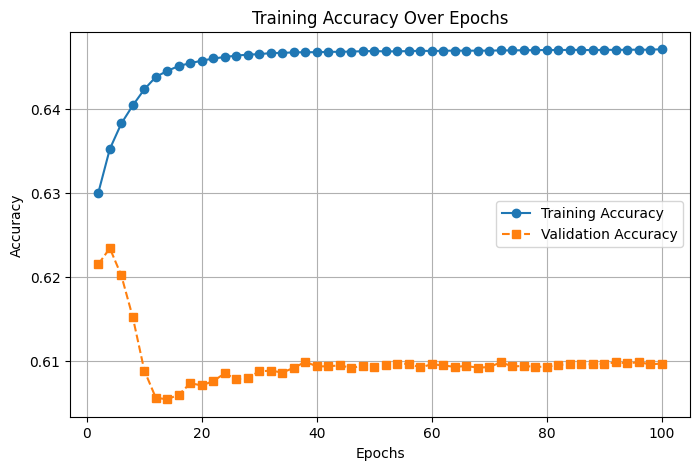

In [12]:
# Plot the train and validation accuracies
plot_train_accuracy(total_train_accuracies, total_val_accuracies)

In [13]:
# Plot all accuracies

training_dnn_baseline_accuracies = [
    0.6326, 0.6387, 0.6420, 0.6447, 0.6468, 0.6483, 0.6493, 0.6500, 0.6506, 0.6509,
    0.6512, 0.6509, 0.6516, 0.6517, 0.6519, 0.6520, 0.6520, 0.6521, 0.6520, 0.6522,
    0.6522, 0.6522, 0.6522, 0.6522, 0.6522, 0.6523, 0.6522, 0.6523, 0.6523, 0.6522,
    0.6522, 0.6523, 0.6523, 0.6523, 0.6523, 0.6523, 0.6523, 0.6524, 0.6524, 0.6524,
    0.6524, 0.6524, 0.6524, 0.6524, 0.6524, 0.6524, 0.6524, 0.6524, 0.6525, 0.6525
]



validation_dnn_baseline_accuracies = [
    0.6255, 0.6283, 0.6300, 0.6249, 0.6202, 0.6175, 0.6151, 0.6162, 0.6166, 0.6174,
    0.6173, 0.6194, 0.6177, 0.6167, 0.6179, 0.6178, 0.6177, 0.6178, 0.6182, 0.6177,
    0.6177, 0.6178, 0.6174, 0.6182, 0.6176, 0.6177, 0.6180, 0.6177, 0.6178, 0.6179,
    0.6178, 0.6178, 0.6178, 0.6180, 0.6177, 0.6182, 0.6181, 0.6180, 0.6179, 0.6181,
    0.6182, 0.6178, 0.6177, 0.6182, 0.6185, 0.6185, 0.6175, 0.6180, 0.6180, 0.6177
]


training_dnn_enhanced_accuracies = [
    0.6028, 0.6055, 0.6087, 0.6099, 0.6101, 0.6135, 0.6142, 0.6157, 0.6159, 0.6164,
    0.6168, 0.6172, 0.6168, 0.6170, 0.6173, 0.6173, 0.6175, 0.6175, 0.6177, 0.6167,
    0.6170, 0.6170, 0.6177, 0.6177, 0.6179, 0.6178, 0.6176, 0.6165, 0.6179, 0.6178,
    0.6182, 0.6176, 0.6180, 0.6175, 0.6178, 0.6178, 0.6174, 0.6180, 0.6176, 0.6180,
    0.6177, 0.6171, 0.6177, 0.6180, 0.6173, 0.6182, 0.6179, 0.6185, 0.6179, 0.6177
]

validation_dnn_enhanced_accuracies = val_accuracies = [
    0.5969, 0.6042, 0.6101, 0.6161, 0.6214, 0.6259, 0.6251, 0.6267, 0.6262, 0.6272,
    0.6268, 0.6251, 0.6251, 0.6256, 0.6250, 0.6243, 0.6240, 0.6242, 0.6243, 0.6237,
    0.6241, 0.6241, 0.6236, 0.6239, 0.6251, 0.6236, 0.6233, 0.6241, 0.6234, 0.6235,
    0.6235, 0.6233, 0.6235, 0.6235, 0.6234, 0.6232, 0.6234, 0.6233, 0.6234, 0.6234,
    0.6232, 0.6234, 0.6231, 0.6233, 0.6235, 0.6232, 0.6233, 0.6230, 0.6230, 0.6230
]


training_dnn_pca_accuracies = [
    0.6301, 0.6353, 0.6383, 0.6405, 0.6424, 0.6439, 0.6446, 0.6452, 0.6455, 0.6458, 
    0.6461, 0.6462, 0.6464, 0.6465, 0.6466, 0.6467, 0.6467, 0.6468, 0.6468, 0.6468, 
    0.6468, 0.6468, 0.6468, 0.6469, 0.6469, 0.6469, 0.6469, 0.6469, 0.6469, 0.6469, 
    0.6470, 0.6469, 0.6470, 0.6470, 0.6470, 0.6470, 0.6470, 0.6470, 0.6470, 0.6470, 
    0.6470, 0.6471, 0.6471, 0.6471, 0.6471, 0.6470, 0.6471, 0.6471, 0.6471, 0.6471, 
    0.6472
]

validation_dnn_pca_accuracies = [
    0.6215, 0.6234, 0.6202, 0.6152, 0.6089, 0.6056, 0.6054, 0.6060, 0.6074, 0.6071, 
    0.6076, 0.6085, 0.6078, 0.6080, 0.6088, 0.6089, 0.6086, 0.6092, 0.6099, 0.6094, 
    0.6094, 0.6095, 0.6092, 0.6094, 0.6093, 0.6095, 0.6097, 0.6097, 0.6092, 0.6096, 
    0.6095, 0.6093, 0.6094, 0.6092, 0.6093, 0.6099, 0.6094, 0.6094, 0.6093, 0.6093, 
    0.6095, 0.6097, 0.6096, 0.6096, 0.6097, 0.6098, 0.6097, 0.6099, 0.6096, 0.6097
]

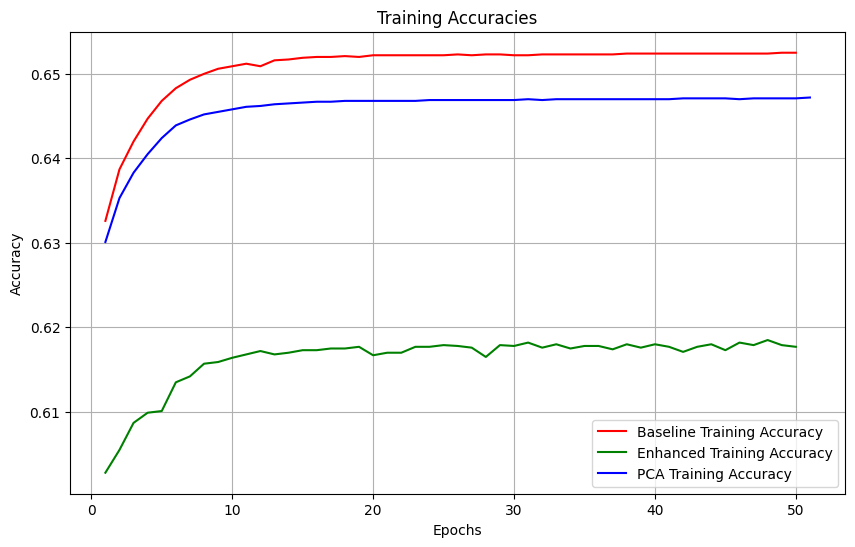

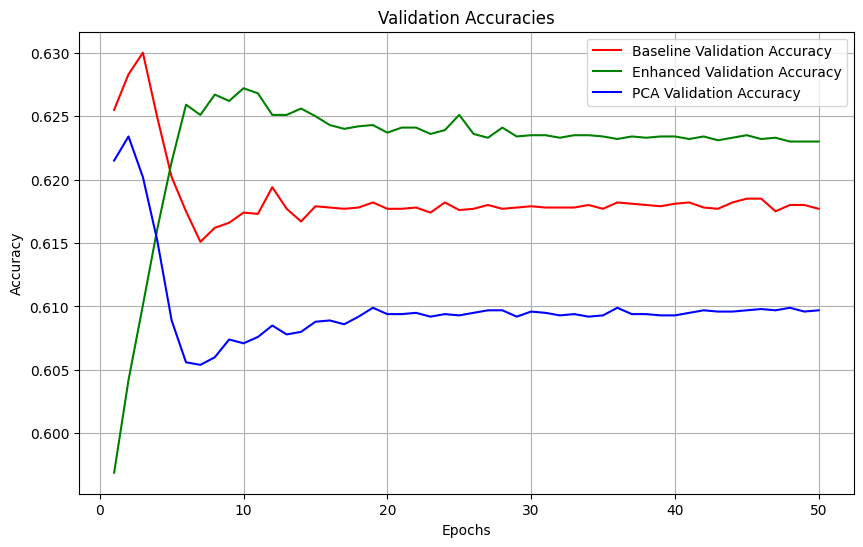

In [14]:
import matplotlib.pyplot as plt

# Training Accuracies
epochs_baseline_train = range(1, len(training_dnn_baseline_accuracies) + 1)
epochs_enhanced_train = range(1, len(training_dnn_enhanced_accuracies) + 1)
epochs_pca_train = range(1, len(training_dnn_pca_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_baseline_train, training_dnn_baseline_accuracies, 'r-', label='Baseline Training Accuracy')
plt.plot(epochs_enhanced_train, training_dnn_enhanced_accuracies, 'g-', label='Enhanced Training Accuracy')
plt.plot(epochs_pca_train, training_dnn_pca_accuracies, 'b-', label='PCA Training Accuracy')
plt.title('Training Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Validation Accuracies
epochs_baseline_val = range(1, len(validation_dnn_baseline_accuracies) + 1)
epochs_enhanced_val = range(1, len(validation_dnn_enhanced_accuracies) + 1)
epochs_pca_val = range(1, len(validation_dnn_pca_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_baseline_val, validation_dnn_baseline_accuracies, 'r-', label='Baseline Validation Accuracy')
plt.plot(epochs_enhanced_val, validation_dnn_enhanced_accuracies, 'g-', label='Enhanced Validation Accuracy')
plt.plot(epochs_pca_val, validation_dnn_pca_accuracies, 'b-', label='PCA Validation Accuracy')
plt.title('Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()